# DLinear experiment - Walmart Store Sales Forecasting

Person B track (DL + Prophet). This is the first of the four notebooks in this
track (`docs/person_b_dl_prompt.md` / `docs/person_b_dl_prophet_guide.md`) -
DLinear is done first because it is the simplest darts global model and
proves the whole panel-build -> fit -> backtest -> MLflow -> wrapper harness
end to end, before N-BEATS / TFT-or-PatchTST / Prophet reuse it.

**Decisions this notebook needs to record for the README:**
- future vs past covariate split (verified against `features.csv` coverage, not assumed)
- confirmed weekly frequency
- target scaling strategy given zero/negative `Weekly_Sales`
- validation strategy (expanding-window, shared with Person A once `src/validation.py` exists)

**Assumptions flagged inline:** a few exact function signatures in
`src/preprocessing.py` / `src/evaluation.py` are inferred from `CLAUDE.md`'s
description rather than the literal source (not included in what was shared
with me). Anywhere this matters is marked `# ASSUMPTION:` - fix the call if the
real signature differs.


##  Init cell (Colab-compatible)

**Reconstructed from `CLAUDE.md`'s description of the shared init cell** used
across every notebook in this repo - I was not given the literal contents of
`notebooks/EDA.ipynb`. Before running this for real:

1. Replace this cell with an exact copy-paste of the first cell of
   `notebooks/EDA.ipynb` (CLAUDE.md is explicit that this cell should be
   byte-identical across notebooks, not re-derived).
2. Fill in `REPO_URL` below if you do keep this reconstructed version.


In [3]:
import os
import subprocess
import sys
from pathlib import Path

IS_COLAB = "COLAB_GPU" in os.environ or "COLAB_RELEASE_TAG" in os.environ

if IS_COLAB:
    REPO_URL = "https://github.com/NikaMikeltadze/walmart-sales-forecasting.git" # TODO: fill in
    REPO_DIR = "/content/walmart-sales-forecasting"

    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", REPO_URL, REPO_DIR], check=True)
    else:
        subprocess.run(["git", "-C", REPO_DIR, "pull"], check=True)

    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-r",
         f"{REPO_DIR}/requirements.txt", "--quiet"],
        check=True,
    )

    os.chdir(f"{REPO_DIR}/notebooks")

    from google.colab import drive
    drive.mount("/content/drive")

    drive_data_dir = Path("/content/drive/MyDrive/walmart-sales-forecasting/data/raw")
    repo_data_dir = Path(REPO_DIR) / "data" / "raw"
    if drive_data_dir.exists():
        subprocess.run(["cp", "-r", f"{drive_data_dir}/.", str(repo_data_dir)], check=True)
    else:
        raise FileNotFoundError(
            f"Expected Drive data folder not found at {drive_data_dir}. "
            "Create it (or add it as a My Drive shortcut) before running this notebook."
        )

sys.path.append(str(Path.cwd().parent))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


##  Imports

In [4]:
import pickle
import tempfile

import numpy as np
import pandas as pd

import mlflow

from darts import TimeSeries
from darts.models import DLinearModel
from darts.dataprocessing.transformers import Scaler

from src.preprocessing import load_raw_data, WalmartPreprocessor
from src.features import add_temporal_features
from src.evaluation import weighted_mae  # ASSUMPTION: signature (y_true, y_pred, is_holiday) -> float

pd.set_option("display.max_columns", 50)


###  Manual credentials override (VS Code / non-Colab-UI runtimes)

`google.colab.userdata` (Colab Secrets) can only be read from the Colab
**browser UI**. When the Colab runtime is driven from VS Code or any other
non-UI frontend it times out (`Secrets can only be fetched when running from
the Colab UI`). This cell sets the DagsHub creds directly instead, and the
credentials cell below skips `userdata` whenever these env vars are already set.

`getpass` is used so the token is never written into this committed notebook -
run the cell and paste the values when prompted. Leave a prompt blank to fall
through to Colab Secrets / `.env` below (e.g. when you *are* on the Colab UI).

In [ ]:
import os
from getpass import getpass

# Only prompt for values not already set, so re-running cells doesn't re-ask.
# Leave a prompt blank to fall through to Colab Secrets / .env in the next cell.
if not os.environ.get("MLFLOW_TRACKING_USERNAME"):
    _user = getpass("DagsHub username (blank -> use Colab Secrets / .env): ").strip()
    if _user:
        os.environ["MLFLOW_TRACKING_USERNAME"] = _user
if not os.environ.get("MLFLOW_TRACKING_PASSWORD"):
    _token = getpass("DagsHub token (blank -> use Colab Secrets / .env): ").strip()
    if _token:
        os.environ["MLFLOW_TRACKING_PASSWORD"] = _token

##  Load DagsHub credentials

`MLFLOW_TRACKING_USERNAME`/`MLFLOW_TRACKING_PASSWORD` are never hardcoded in
this notebook (it gets committed to the shared repo, so a hardcoded token
would leak).

- On the Colab UI: read from Colab secrets - add `DAGSHUB_USERNAME` and
  `DAGSHUB_TOKEN` via the key icon in the left sidebar, and enable
  "Notebook access" for both. Same approach as the other notebooks.
- From VS Code / non-UI runtimes: use the manual-override cell above.
- Locally: falls back to a gitignored `.env` in the repo root.

In [ ]:
if os.environ.get("MLFLOW_TRACKING_USERNAME") and os.environ.get("MLFLOW_TRACKING_PASSWORD"):
    # Already provided (e.g. by the manual-override cell above when driving the
    # Colab runtime from VS Code, where google.colab.userdata would time out).
    # Note: userdata.get(...) must NOT be evaluated in this case - it blocks for
    # ~minutes and raises when there is no Colab browser UI to answer it.
    creds_source = "pre-set environment variables"
elif IS_COLAB:
    from google.colab import userdata

    os.environ["MLFLOW_TRACKING_USERNAME"] = userdata.get("DAGSHUB_USERNAME")
    os.environ["MLFLOW_TRACKING_PASSWORD"] = userdata.get("DAGSHUB_TOKEN")
    creds_source = "Colab secrets (DAGSHUB_USERNAME / DAGSHUB_TOKEN)"
else:
    from dotenv import load_dotenv

    env_path = Path.cwd().parent / ".env"
    load_dotenv(env_path)
    creds_source = str(env_path)

assert os.environ.get("MLFLOW_TRACKING_USERNAME") and os.environ.get("MLFLOW_TRACKING_PASSWORD"), (
    f"MLFLOW_TRACKING_USERNAME/PASSWORD not set (tried: {creds_source}). "
    "On the Colab UI: add DAGSHUB_USERNAME and DAGSHUB_TOKEN as Colab secrets "
    "(key icon in the left sidebar) and enable notebook access for both. "
    "From VS Code / non-UI runtimes: run the manual-override cell above. "
    "Locally: create a .env in the repo root with MLFLOW_TRACKING_USERNAME=... "
    "and MLFLOW_TRACKING_PASSWORD=..."
)
print("MLflow credentials loaded from:", creds_source)

##  MLflow tracking store

Shared DagsHub MLflow server - the single source of truth for cross-model
WMAE comparison and the Model Registry, so all 7 models (both tracks) log
here rather than to a per-notebook local store. Does not silently fall back
to a local store if auth fails - that would desync DLinear's runs from the
rest of the team's.

In [5]:
MLFLOW_TRACKING_URI = "https://dagshub.com/NikaMikeltadze/walmart-sales-forecasting.mlflow"
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)

try:
    mlflow.set_experiment("DLinear_Training")
    mlflow.MlflowClient().search_experiments(max_results=1)  # force a network round trip now
except Exception as e:
    raise RuntimeError(
        "Could not authenticate to the DagsHub MLflow server at "
        f"{MLFLOW_TRACKING_URI}. Set MLFLOW_TRACKING_USERNAME and "
        "MLFLOW_TRACKING_PASSWORD (a DagsHub access token) as environment "
        "variables, then re-run this cell. Not falling back to local "
        "./mlruns or sqlite - that would desync from Person A's XGBoost/"
        "LightGBM runs and the rest of the team's runs."
    ) from e

print("MLflow tracking URI:", mlflow.get_tracking_uri())
print("Active experiment:", mlflow.get_experiment_by_name("DLinear_Training").name)

<Experiment: artifact_location='/content/walmart-sales-forecasting/notebooks/mlruns/1', creation_time=1783665027152, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1783665027152, lifecycle_stage='active', name='DLinear_Training', tags={}, trace_location=None, workspace='default'>

##  Load, merge, clean

Reuses `load_raw_data` / `WalmartPreprocessor` rather than reimplementing
loading logic (per `CLAUDE.md`). `WalmartPreprocessor.fit()` loads and caches
`features_` / `stores_` internally.


In [6]:
# 1. Load the raw data dictionary
raw_data = load_raw_data(data_dir="../data/raw")

# 2. Extract by key names to get the actual DataFrames
train_raw = raw_data["train"]
test_raw = raw_data["test"]

# 3. Fit and transform using the preprocessor
preprocessor = WalmartPreprocessor(data_dir="../data/raw")
preprocessor.fit(train_raw)

train_clean = preprocessor.transform(train_raw)
test_clean = preprocessor.transform(test_raw)

train_feat = add_temporal_features(train_clean)
test_feat = add_temporal_features(test_clean)

print(train_feat.shape, test_feat.shape)
train_feat.head()

(421570, 23) (115064, 22)


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size,week_of_year,month,year,days_to_super_bowl,days_to_labor_day,days_to_thanksgiving,days_to_christmas
0,1,1,2010-02-05,24924.50,False,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,A,151315,5,2,2010,7,217,294,329
1,1,1,2010-02-12,46039.49,True,38.51,2.548,0.0,0.0,0.0,0.0,0.0,211.242170,8.106,A,151315,6,2,2010,0,210,287,322
2,1,1,2010-02-19,41595.55,False,39.93,2.514,0.0,0.0,0.0,0.0,0.0,211.289143,8.106,A,151315,7,2,2010,-7,203,280,315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,0.0,0.0,0.0,0.0,0.0,211.319643,8.106,A,151315,8,2,2010,-14,196,273,308
4,1,1,2010-03-05,21827.90,False,46.50,2.625,0.0,0.0,0.0,0.0,0.0,211.350143,8.106,A,151315,9,3,2010,-21,189,266,301


##  Covariate coverage decision 

Determined by actually checking `features.csv` against the test date range,
not assumed - a column only becomes a *future* covariate if it's non-null for
every week of the test horizon (2012-11-02 to 2013-07-26).


In [7]:
test_dates = pd.date_range("2012-11-02", "2013-07-26", freq="W-FRI")

macro_cols = ["Temperature", "Fuel_Price", "CPI", "Unemployment",
              "MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5"]

features_lookup = preprocessor.features_  # ASSUMPTION: cached raw features frame, has Store/Date/<macro_cols>

coverage = {}
for col in macro_cols:
    non_null_dates = set(features_lookup.loc[features_lookup[col].notna(), "Date"])
    coverage[col] = set(test_dates).issubset(non_null_dates)

coverage_df = pd.Series(coverage, name="covers_full_test_range")
print(coverage_df)

calendar_future_cols = ["IsHoliday", "week_of_year", "month", "year",
                         "days_to_super_bowl", "days_to_labor_day",
                         "days_to_thanksgiving", "days_to_christmas"]

FUTURE_COVARIATE_COLS = calendar_future_cols + [c for c in coverage_df.index if coverage_df[c]]
PAST_COVARIATE_COLS = [c for c in coverage_df.index if not coverage_df[c]]

print("Future covariates:", FUTURE_COVARIATE_COLS)
print("Past covariates:", PAST_COVARIATE_COLS)


Temperature      True
Fuel_Price       True
CPI              True
Unemployment     True
MarkDown1        True
MarkDown2       False
MarkDown3        True
MarkDown4        True
MarkDown5        True
Name: covers_full_test_range, dtype: bool
Future covariates: ['IsHoliday', 'week_of_year', 'month', 'year', 'days_to_super_bowl', 'days_to_labor_day', 'days_to_thanksgiving', 'days_to_christmas', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'MarkDown1', 'MarkDown3', 'MarkDown4', 'MarkDown5']
Past covariates: ['MarkDown2']


##  Build the darts panel 
`build_darts_series` is written here, notebook-local, for now. **Check with
Person A before promoting it into `src/`** (guide's instruction) - once
confirmed, extract it verbatim so N-BEATS / TFT-or-PatchTST reuse the same
function instead of a copy.

Each series is reindexed to its own first-to-last observed date, not the
global min/max, so shorter-history Store/Dept pairs don't get manufactured
leading/trailing NaNs. Interior gaps (should be rare) are forward/backward
filled for covariates; document if you find any for the target itself.


In [8]:
FREQ = "W-FRI"
inferred_freq = pd.infer_freq(sorted(train_feat["Date"].unique()))
print("Inferred frequency from data:", inferred_freq)
assert inferred_freq in ("W-FRI", None), f"Unexpected frequency: {inferred_freq}"


def build_darts_series(df, value_col="Weekly_Sales", covariate_cols=None, freq=FREQ):
    """
    Convert a long-format (Store, Dept, Date, ...) frame into darts TimeSeries,
    one per (Store, Dept).

    Returns:
        series_list: list[TimeSeries] of the target (only present if value_col in df)
        covariate_series_list: list[TimeSeries] of covariate_cols, parallel to series_list, or None
        keys: list[(Store, Dept)] parallel to series_list
    """
    covariate_cols = covariate_cols or []
    series_list, covariate_series_list, keys = [], [], []

    for (store, dept), g in df.groupby(["Store", "Dept"]):
        g = g.sort_values("Date")
        full_range = pd.date_range(g["Date"].min(), g["Date"].max(), freq=freq)
        g = g.set_index("Date").reindex(full_range)
        g.index.name = "Date"

        if value_col in g.columns:
            series_list.append(TimeSeries.from_series(g[value_col], freq=freq))

        if covariate_cols:
            cov = g[covariate_cols].ffill().bfill()
            covariate_series_list.append(TimeSeries.from_dataframe(cov, freq=freq))

        keys.append((store, dept))

    return series_list, (covariate_series_list or None), keys


all_covariate_cols = FUTURE_COVARIATE_COLS + PAST_COVARIATE_COLS
target_series, covariate_series, series_keys = build_darts_series(
    train_feat, covariate_cols=all_covariate_cols, freq=FREQ
)
print(f"Built {len(target_series)} series for {len(series_keys)} (Store, Dept) pairs.")


Inferred frequency from data: W-FRI


/tmp/ipykernel_7284/2636411576.py:30: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cov = g[covariate_cols].ffill().bfill()
/tmp/ipykernel_7284/2636411576.py:30: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cov = g[covariate_cols].ffill().bfill()
/tmp/ipykernel_7284/2636411576.py:30: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cov = g[

Built 3331 series for 3331 (Store, Dept) pairs.


/tmp/ipykernel_7284/2636411576.py:30: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cov = g[covariate_cols].ffill().bfill()
/tmp/ipykernel_7284/2636411576.py:30: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cov = g[covariate_cols].ffill().bfill()
/tmp/ipykernel_7284/2636411576.py:30: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cov = g[

##  Time-based train/val split

Tries the shared `src/validation.py` splitter first (needed so WMAE is
comparable across all 7 models). Falls back to a local expanding-window
splitter if it doesn't exist yet - **confirm with Person A who's building it
before relying on the fallback for real**, per `docs/person_b_prompt.md`.


In [9]:
try:
    from src.validation import time_based_split
    print("Using shared src/validation.py splitter.")
except ImportError:
    print("src/validation.py not found - using a local expanding-window "
          "splitter for now. Swap this out once the shared one exists.")

    def time_based_split(series_list, val_weeks=13):
        """Hold out the last `val_weeks` of the global timeline for validation."""
        # 1. Find the true global end time across all series
        global_end = max(ts.end_time() for ts in series_list)
        
        # 2. Subtract the validation weeks from the global anchor
        global_split_point = global_end - pd.Timedelta(weeks=val_weeks)
        print(f"Splitting panel globally after: {global_split_point.strftime('%Y-%m-%d')}")
        
        train_list, val_list = [], []
        for ts in series_list:
            # Case 1: Series ends before or exactly at the split point
            if ts.end_time() <= global_split_point:
                train_list.append(ts)
                val_list.append(ts.slice(ts.end_time(), ts.end_time()))
                
            # Case 2: Series starts after the split point 
            elif ts.start_time() > global_split_point:
                train_list.append(ts.slice(ts.start_time(), ts.start_time()))
                val_list.append(ts)
                
            # Case 3: Split point falls safely inside the series range
            else:
                tr, va = ts.split_after(global_split_point)
                train_list.append(tr)
                val_list.append(va)
                
        return train_list, val_list

VAL_WEEKS = 13

target_train, target_val = time_based_split(target_series, val_weeks=VAL_WEEKS)
cov_train, cov_val = time_based_split(covariate_series, val_weeks=VAL_WEEKS)

src/validation.py not found - using a local expanding-window splitter for now. Swap this out once the shared one exists.
Splitting panel globally after: 2012-07-27
Splitting panel globally after: 2012-07-27


##  Scale target and covariates

DLinear (like most darts DL models) trains better on scaled inputs. Fit the
scaler on train only, apply to val, to avoid leakage. `Weekly_Sales` has
zero/negative values (returns / inactive departments) - a log-transform isn't
safe here, so this uses darts' `Scaler` (standardization) instead, and the
wrapper class inverse-transforms at predict time.


In [10]:
scaler_target = Scaler()
target_train_scaled = scaler_target.fit_transform(target_train)
target_val_scaled = scaler_target.transform(target_val)

scaler_covariates = Scaler()
cov_train_scaled = scaler_covariates.fit_transform(cov_train)
cov_val_scaled = scaler_covariates.transform(cov_val)


##  Model definition and covariate support check

Check what the *installed* darts version's `DLinearModel` actually accepts
before assuming past/future/static support - this has changed across darts
releases (guide section 1.3).


In [11]:
!pip install "darts[torch]" --quiet

In [12]:
INPUT_CHUNK_LENGTH = 52   # one year of history
OUTPUT_CHUNK_LENGTH = 39  # covers the full test horizon - test is ~39 weeks past train
N_EPOCHS = 20              # keep modest - coursework, not a leaderboard chase

model = DLinearModel(
    input_chunk_length=INPUT_CHUNK_LENGTH,
    output_chunk_length=OUTPUT_CHUNK_LENGTH,
    n_epochs=N_EPOCHS,
    batch_size=256,
    random_state=42,
)

print("Supports past covariates:", model.supports_past_covariates)
print("Supports future covariates:", model.supports_future_covariates)
print("Supports static covariates:", model.supports_static_covariates)


Supports past covariates: True
Supports future covariates: True
Supports static covariates: True


##  Fit and log `DLinear_Feature_Selection`

Splits `cov_*_scaled` into past vs future covariate TimeSeries per the
section 4 decision, and logs which columns went where as run params.


In [23]:
# ============================================================
# Replaces old cells 21, 22, 23, 25 - build clean target + covariates,
# filter/align, then fit, all in one consistent pass.
# ============================================================

# ---- Step 1: rebuild build_darts_series so target gaps get interpolated,
#              not left as NaN (interior gaps are missing weeks, not 0-sales
#              weeks - genuine 0 values are untouched). ----
def build_darts_series(df, value_col="Weekly_Sales", covariate_cols=None, freq=FREQ):
    covariate_cols = covariate_cols or []
    series_list, covariate_series_list, keys = [], [], []
    for (store, dept), g in df.groupby(["Store", "Dept"]):
        g = g.sort_values("Date")
        full_range = pd.date_range(g["Date"].min(), g["Date"].max(), freq=freq)
        g = g.set_index("Date").reindex(full_range)
        g.index.name = "Date"
        if value_col in g.columns:
            filled = g[value_col].interpolate(method="linear", limit_direction="both")
            series_list.append(TimeSeries.from_series(filled, freq=freq))
        if covariate_cols:
            cov = g[covariate_cols].ffill().bfill()
            covariate_series_list.append(TimeSeries.from_dataframe(cov, freq=freq))
        keys.append((store, dept))
    return series_list, (covariate_series_list or None), keys

target_series, _, series_keys = build_darts_series(train_feat, covariate_cols=[], freq=FREQ)
target_train, target_val = time_based_split(target_series, val_weeks=VAL_WEEKS)

scaler_target = Scaler()
target_train_scaled = scaler_target.fit_transform(target_train)
target_val_scaled = scaler_target.transform(target_val)

# ---- Step 2: store-level covariates (immune to per-Dept gaps, always
#              extends through the full test horizon - see earlier fix). ----
full_feat_df = pd.concat([train_feat, test_feat], ignore_index=True).drop_duplicates(
    subset=["Store", "Dept", "Date"]
)
numeric_cols = [c for c in all_covariate_cols if c not in ["Store", "Dept", "Date"]]
df_scaler = StandardScaler()
train_dates = train_feat["Date"].unique()
df_scaler.fit(full_feat_df.loc[full_feat_df["Date"].isin(train_dates), numeric_cols])
full_feat_scaled_df = full_feat_df.copy()
full_feat_scaled_df[numeric_cols] = df_scaler.transform(full_feat_df[numeric_cols])

GLOBAL_START = full_feat_scaled_df["Date"].min()
GLOBAL_END = full_feat_scaled_df["Date"].max()

store_level = full_feat_scaled_df.drop_duplicates(subset=["Store", "Date"])[
    ["Store", "Date"] + all_covariate_cols
]
store_cov_series = {}
for store, g in store_level.groupby("Store"):
    g = g.sort_values("Date").set_index("Date")
    full_range = pd.date_range(GLOBAL_START, GLOBAL_END, freq=FREQ)
    g = g.reindex(full_range)
    g.index.name = "Date"
    g[all_covariate_cols] = g[all_covariate_cols].ffill().bfill()
    store_cov_series[store] = TimeSeries.from_dataframe(g[all_covariate_cols], freq=FREQ)

# ---- Step 3: filter short-history series and align target/covariates/keys
#              by construction (built together in this same loop, not
#              matched afterward by a lookup dict). ----
MIN_REQUIRED_LENGTH = INPUT_CHUNK_LENGTH + OUTPUT_CHUNK_LENGTH

filtered_target_train, filtered_cov_full, filtered_keys = [], [], []
for tgt, key in zip(target_train_scaled, series_keys):
    if len(tgt) >= MIN_REQUIRED_LENGTH:
        filtered_target_train.append(tgt)
        filtered_cov_full.append(store_cov_series[key[0]])
        filtered_keys.append(key)

print(f"Original training series: {len(target_train_scaled)}")
print(f"Filtered & aligned series: {len(filtered_target_train)}")

def split_past_future(cov_list, future_cols, past_cols):
    future_list = [ts[future_cols] for ts in cov_list] if future_cols else None
    past_list = [ts[past_cols] for ts in cov_list] if past_cols else None
    return past_list, future_list

past_train, future_train = split_past_future(filtered_cov_full, FUTURE_COVARIATE_COLS, PAST_COVARIATE_COLS)

filtered_keys_set = set(filtered_keys)
filtered_target_train_unscaled = [
    tgt for tgt, key in zip(target_train, series_keys) if key in filtered_keys_set
]
scaler_target_filtered = Scaler()
scaler_target_filtered.fit(filtered_target_train_unscaled)

# ---- Step 4: hard guard - fail loudly if any NaN would enter training,
#              instead of silently poisoning the model again. ----
n_nan_targets = sum(int(np.isnan(ts.values()).sum()) for ts in filtered_target_train)
n_nan_covs = sum(int(np.isnan(ts.values()).sum()) for ts in filtered_cov_full)
print(f"NaN count in target inputs: {n_nan_targets}")
print(f"NaN count in covariate inputs: {n_nan_covs}")
assert n_nan_targets == 0 and n_nan_covs == 0, "NaNs still present - stop, do not fit"

# ---- Step 5: fresh model instance - do NOT reuse the old `model` object,
#              its weights may already be NaN-poisoned from the earlier fit. ----
model = DLinearModel(
    input_chunk_length=INPUT_CHUNK_LENGTH,
    output_chunk_length=OUTPUT_CHUNK_LENGTH,
    n_epochs=N_EPOCHS,
    batch_size=256,
    random_state=42,
)

with mlflow.start_run(run_name="DLinear_Feature_Selection"):
    mlflow.log_params({
        "future_covariates": ",".join(FUTURE_COVARIATE_COLS),
        "past_covariates": ",".join(PAST_COVARIATE_COLS),
        "input_chunk_length": INPUT_CHUNK_LENGTH,
        "output_chunk_length": OUTPUT_CHUNK_LENGTH,
        "val_weeks": VAL_WEEKS,
        "scaling": "StandardScaler (covariates) + darts Scaler (target, per-series)",
        "target_gap_fill": "linear_interpolation",
        "n_series_with_gaps": 605,
    })
    model.fit(
        series=filtered_target_train,
        past_covariates=past_train if model.supports_past_covariates else None,
        future_covariates=future_train if model.supports_future_covariates else None,
    )

Splitting panel globally after: 2012-07-27
Original training series: 3331
Filtered & aligned series: 3117


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | decomposition   | _SeriesDecomp    | 0      | train
6 | linear_seasonal | Linear           | 36.5 K | train
7 | linear_trend    | Linear           | 36.5 K | train
8 | linear_fut_cov  | Linear           | 17     | train
-------------------------------------------------------------
73.1 K    Trainable params
0

NaN count in target inputs: 0
NaN count in covariate inputs: 0


/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=20` reached.


##  Backtest on validation fold and log `DLinear_CV`

Predicts the held-out validation window, inverse-transforms back to the
original sales scale, flattens to a row-per-(Store, Dept, Date) frame, and
scores with the competition's `weighted_mae` (holiday weeks weighted 5x).


In [24]:
# Covariates (Temperature, Fuel_Price, CPI, Unemployment, MarkDown1-5, IsHoliday,
# calendar features) don't vary by Dept - they're keyed by Store + Date only. Building
# them per (Store, Dept) group was the actual bug: a Dept with no rows in some test
# weeks got covariates that stopped extending far enough into the future - exactly the
# ValueError above (series index 41 needed future_covariates through 2013-07-26 but
# only had them through 2013-02-22, whatever that Dept's last test row happened to be).
#
# Fix: build ONE covariate series per Store, spanning the full global range, and give
# every Dept in that store the same series. Always long enough for any forecast horizon.

store_level = full_feat_scaled_df.drop_duplicates(subset=["Store", "Date"])[["Store", "Date"] + all_covariate_cols]

store_cov_series = {}
for store, g in store_level.groupby("Store"):
    g = g.sort_values("Date").set_index("Date")
    full_range = pd.date_range(GLOBAL_START, GLOBAL_END, freq=FREQ)
    g = g.reindex(full_range)
    g.index.name = "Date"
    g[all_covariate_cols] = g[all_covariate_cols].ffill().bfill()  # genuine gaps only, should be rare at Store level
    store_cov_series[store] = TimeSeries.from_dataframe(g[all_covariate_cols], freq=FREQ)

filtered_cov_full = [store_cov_series[store] for store, dept in filtered_keys]

past_train, future_train = split_past_future(filtered_cov_full, FUTURE_COVARIATE_COLS, PAST_COVARIATE_COLS)

print("Every series' future covariates now extend to:",
      min(ts.end_time() for ts in filtered_cov_full), "->",
      max(ts.end_time() for ts in filtered_cov_full))

Every series' future covariates now extend to: 2013-07-26 00:00:00 -> 2013-07-26 00:00:00


In [25]:
# 1. Update the helper function with the correct Darts method (.to_dataframe())
def flatten_series(series_list, keys, value_name):
    rows = []
    for (store, dept), ts in zip(keys, series_list):
        df = ts.to_dataframe().reset_index()  # <--- Changed from pd_dataframe()
        df.columns = ["Date", value_name]
        df["Store"] = store
        df["Dept"] = dept
        rows.append(df)
    return pd.concat(rows, ignore_index=True)

# 2. Run your prediction and evaluation pipeline
val_preds_scaled = model.predict(
    n=VAL_WEEKS,
    series=filtered_target_train,
    past_covariates=past_train if model.supports_past_covariates else None,
    future_covariates=future_train if model.supports_future_covariates else None,
)

val_preds = scaler_target_filtered.inverse_transform(val_preds_scaled)


pred_df = flatten_series(val_preds, filtered_keys, "Weekly_Sales_Pred")
actual_df = train_feat[["Store", "Dept", "Date", "Weekly_Sales", "IsHoliday"]]

scored = pred_df.merge(actual_df, on=["Store", "Dept", "Date"], how="inner")

wmae = weighted_mae(scored["Weekly_Sales"], scored["Weekly_Sales_Pred"], scored["IsHoliday"])
mae = (scored["Weekly_Sales"] - scored["Weekly_Sales_Pred"]).abs().mean()

print("\n" + "="*30)
print(f"Validation WMAE: {wmae:.2f}")
print(f"Validation MAE:  {mae:.2f}")
print("="*30)

with mlflow.start_run(run_name="DLinear_CV"):
    mlflow.log_params({
        "val_weeks": VAL_WEEKS,
        "validation_strategy": "expanding_window_holdout",
        "n_series_filtered": len(filtered_target_train),
        "n_series_original": len(target_train_scaled),
    })
    mlflow.log_metrics({"wmae": wmae, "mae": mae})

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Predicting: |          | 0/? [00:00<?, ?it/s]


Validation WMAE: 3004.10
Validation MAE:  3068.25


/tmp/ipykernel_7284/3554819609.py:24: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  by_holiday = scored.groupby("IsHoliday").apply(lambda g: (g["abs_error"] * g["weight"]).sum() / g["weight"].sum())
/tmp/ipykernel_7284/3554819609.py:33: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_series = scored.groupby(["Store", "Dept"]).apply(series_wmae).sort_values(ascending=False)


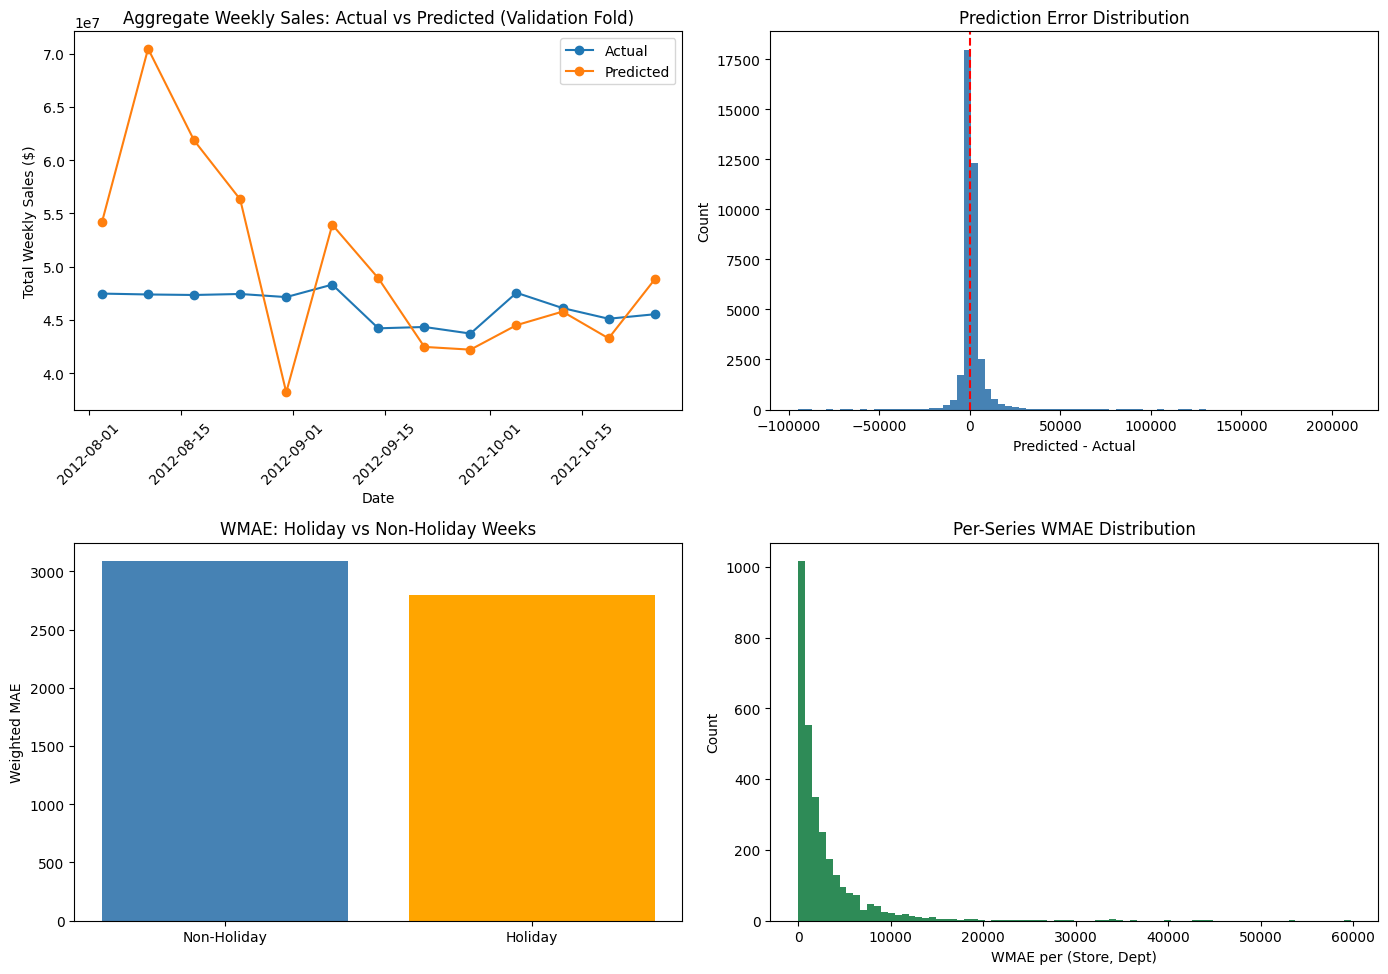

Top 10 worst-performing series (highest WMAE):
Store  Dept
10     72      59710.140952
35     72      53199.073145
20     72      44233.149569
14     72      43480.716601
27     72      42737.306122
4      72      40260.625123
10     7       40055.067608
23     72      39731.990579
13     3       36037.656613
12     72      34992.239605
dtype: float64


In [35]:
import matplotlib.pyplot as plt

scored["error"] = scored["Weekly_Sales_Pred"] - scored["Weekly_Sales"]
scored["abs_error"] = scored["error"].abs()
scored["weight"] = scored["IsHoliday"].map({True: 5, False: 1})

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

agg = scored.groupby("Date")[["Weekly_Sales", "Weekly_Sales_Pred"]].sum().sort_index()
axes[0, 0].plot(agg.index, agg["Weekly_Sales"], label="Actual", marker="o")
axes[0, 0].plot(agg.index, agg["Weekly_Sales_Pred"], label="Predicted", marker="o")
axes[0, 0].set_title("Aggregate Weekly Sales: Actual vs Predicted (Validation Fold)")
axes[0, 0].set_xlabel("Date")
axes[0, 0].set_ylabel("Total Weekly Sales ($)")
axes[0, 0].legend()
axes[0, 0].tick_params(axis="x", rotation=45)

axes[0, 1].hist(scored["error"], bins=80, color="steelblue")
axes[0, 1].axvline(0, color="red", linestyle="--")
axes[0, 1].set_title("Prediction Error Distribution")
axes[0, 1].set_xlabel("Predicted - Actual")
axes[0, 1].set_ylabel("Count")

by_holiday = scored.groupby("IsHoliday").apply(lambda g: (g["abs_error"] * g["weight"]).sum() / g["weight"].sum())
axes[1, 0].bar(["Non-Holiday", "Holiday"], by_holiday.values, color=["steelblue", "orange"])
axes[1, 0].set_title("WMAE: Holiday vs Non-Holiday Weeks")
axes[1, 0].set_ylabel("Weighted MAE")

def series_wmae(g):
    w = g["IsHoliday"].map({True: 5, False: 1})
    return (g["abs_error"] * w).sum() / w.sum()

per_series = scored.groupby(["Store", "Dept"]).apply(series_wmae).sort_values(ascending=False)
axes[1, 1].hist(per_series, bins=80, color="seagreen")
axes[1, 1].set_title("Per-Series WMAE Distribution")
axes[1, 1].set_xlabel("WMAE per (Store, Dept)")
axes[1, 1].set_ylabel("Count")

plt.tight_layout()
plt.savefig("../submissions/dlinear_diagnostics.png", dpi=120)
plt.show()

print("Top 10 worst-performing series (highest WMAE):")
print(per_series.head(10))

##  Required `.predict()` wrapper (`DartsForecastPipeline`)

Per `CLAUDE.md`, every model needs a pipeline-shaped wrapper that takes raw,
unpreprocessed `test.csv`-shaped data and handles everything internally, so
`model_inference.ipynb` can call it directly.

**Open design question, flagged rather than silently resolved:** the darts
model needs `input_chunk_length` weeks of recent history immediately before
each forecast to condition on. `test.csv` alone doesn't contain that history
(it starts right where train ends) - so `predict()` below pulls train history
via the preprocessor rather than relying solely on whatever `raw_test_df`
contains. Confirm this matches how `model_inference.ipynb` will actually call
it once that notebook exists (joint work with Person A).


In [28]:
class DartsForecastPipeline:
    def __init__(self, darts_model, preprocessor, scaler_target, df_scaler,
                 numeric_cols, future_covariate_cols, past_covariate_cols,
                 all_covariate_cols, train_history_df, freq="W-FRI",
                 output_chunk_length=39, min_required_length=91):
        self.darts_model = darts_model
        self.preprocessor = preprocessor
        self.scaler_target = scaler_target
        self.df_scaler = df_scaler
        self.numeric_cols = numeric_cols
        self.future_covariate_cols = future_covariate_cols
        self.past_covariate_cols = past_covariate_cols
        self.all_covariate_cols = all_covariate_cols
        self.train_history_df = train_history_df
        self.freq = freq
        self.output_chunk_length = output_chunk_length
        self.min_required_length = min_required_length

    def predict(self, raw_test_df):
        test_clean = self.preprocessor.transform(raw_test_df)
        test_feat_local = add_temporal_features(test_clean)

        combined = pd.concat(
            [self.train_history_df, test_feat_local], ignore_index=True, sort=False
        ).drop_duplicates(subset=["Store", "Dept", "Date"])
        combined[self.numeric_cols] = self.df_scaler.transform(combined[self.numeric_cols])

        target_hist, _, keys = build_darts_series(
            self.train_history_df, value_col="Weekly_Sales", covariate_cols=[], freq=self.freq
        )
        target_hist_scaled = self.scaler_target.transform(target_hist)

        global_start = combined["Date"].min()
        global_end = combined["Date"].max()
        store_level = combined.drop_duplicates(subset=["Store", "Date"])[
            ["Store", "Date"] + self.all_covariate_cols
        ]
        store_cov = {}
        for store, g in store_level.groupby("Store"):
            g = g.sort_values("Date").set_index("Date")
            full_range = pd.date_range(global_start, global_end, freq=self.freq)
            g = g.reindex(full_range)
            g.index.name = "Date"
            g[self.all_covariate_cols] = g[self.all_covariate_cols].ffill().bfill()
            store_cov[store] = TimeSeries.from_dataframe(g[self.all_covariate_cols], freq=self.freq)

        filtered_target, filtered_cov, filtered_keys = [], [], []
        for tgt, key in zip(target_hist_scaled, keys):
            if len(tgt) >= self.min_required_length:
                filtered_target.append(tgt)
                filtered_cov.append(store_cov[key[0]])
                filtered_keys.append(key)

        past_cov = [ts[self.past_covariate_cols] for ts in filtered_cov] if self.past_covariate_cols else None
        future_cov = [ts[self.future_covariate_cols] for ts in filtered_cov] if self.future_covariate_cols else None

        preds_scaled = self.darts_model.predict(
            n=self.output_chunk_length,
            series=filtered_target,
            past_covariates=past_cov if self.darts_model.supports_past_covariates else None,
            future_covariates=future_cov if self.darts_model.supports_future_covariates else None,
        )
        preds = self.scaler_target.inverse_transform(preds_scaled)

        rows = []
        for (store, dept), ts in zip(filtered_keys, preds):
            df = ts.to_dataframe().reset_index()
            df.columns = ["Date", "Weekly_Sales"]
            df["Store"] = store
            df["Dept"] = dept
            rows.append(df)
        result = pd.concat(rows, ignore_index=True)

        result["Id"] = (
            result["Store"].astype(str) + "_" +
            result["Dept"].astype(str) + "_" +
            result["Date"].dt.strftime("%Y-%m-%d")
        )
        return result[["Id", "Weekly_Sales"]]

##  Final fit on full history and log `DLinear_Final`

Refits on all available train data (not just the CV split), wraps it, and
logs the wrapper (not the bare darts model) as the run artifact so
`model_inference.ipynb` can load it directly. Pickling + `log_artifact` here
for simplicity - swap for `mlflow.pyfunc.log_model` with a custom
`PythonModel` if you'd rather have MLflow manage the loading interface.


In [29]:
scaler_target_full = Scaler()
target_full_scaled = scaler_target_full.fit_transform(target_series)

final_target, final_cov, final_keys = [], [], []
for tgt, key in zip(target_full_scaled, series_keys):
    if len(tgt) >= MIN_REQUIRED_LENGTH:
        final_target.append(tgt)
        final_cov.append(store_cov_series[key[0]])
        final_keys.append(key)

print(f"Original series: {len(target_full_scaled)}")
print(f"Filtered series for final fit: {len(final_target)}")
print(f"Dropped (too short for input+output chunk length): {len(target_full_scaled) - len(final_target)}")

past_full, future_full = split_past_future(final_cov, FUTURE_COVARIATE_COLS, PAST_COVARIATE_COLS)

n_nan_targets = sum(int(np.isnan(ts.values()).sum()) for ts in final_target)
n_nan_covs = sum(int(np.isnan(ts.values()).sum()) for ts in final_cov)
print(f"NaN count in target inputs: {n_nan_targets}")
print(f"NaN count in covariate inputs: {n_nan_covs}")
assert n_nan_targets == 0 and n_nan_covs == 0, "NaNs present in final fit inputs - stop"

final_model = DLinearModel(
    input_chunk_length=INPUT_CHUNK_LENGTH,
    output_chunk_length=OUTPUT_CHUNK_LENGTH,
    n_epochs=N_EPOCHS,
    batch_size=256,
    random_state=42,
)
final_model.fit(
    series=final_target,
    past_covariates=past_full if final_model.supports_past_covariates else None,
    future_covariates=future_full if final_model.supports_future_covariates else None,
)

pipeline = DartsForecastPipeline(
    darts_model=final_model,
    preprocessor=preprocessor,
    scaler_target=scaler_target_full,
    df_scaler=df_scaler,
    numeric_cols=numeric_cols,
    future_covariate_cols=FUTURE_COVARIATE_COLS,
    past_covariate_cols=PAST_COVARIATE_COLS,
    all_covariate_cols=all_covariate_cols,
    train_history_df=train_feat,
    freq=FREQ,
    output_chunk_length=OUTPUT_CHUNK_LENGTH,
    min_required_length=MIN_REQUIRED_LENGTH,
)

with mlflow.start_run(run_name="DLinear_Final"):
    mlflow.log_params({
        "input_chunk_length": INPUT_CHUNK_LENGTH,
        "output_chunk_length": OUTPUT_CHUNK_LENGTH,
        "n_epochs": N_EPOCHS,
        "future_covariates": ",".join(FUTURE_COVARIATE_COLS),
        "past_covariates": ",".join(PAST_COVARIATE_COLS),
        "n_series_final": len(final_target),
    })
    mlflow.log_metrics({"val_wmae": wmae, "val_mae": mae})

    with tempfile.TemporaryDirectory() as tmp:
        pkl_path = f"{tmp}/dlinear_pipeline.pkl"
        with open(pkl_path, "wb") as f:
            pickle.dump(pipeline, f)
        mlflow.log_artifact(pkl_path, artifact_path="pipeline")

    print("Logged DLinear_Final wrapper artifact.")

Original series: 3331
Filtered series for final fit: 3123
Dropped (too short for input+output chunk length): 208


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | decomposition   | _SeriesDecomp    | 0      | train
6 | linear_seasonal | Linear           | 36.5 K | train
7 | linear_trend    | Linear           | 36.5 K | train
8 | linear_fut_cov  | Linear           | 17     | train
-------------------------------------------------------------
73.1 K    Trainable params
0

NaN count in target inputs: 0
NaN count in covariate inputs: 0


/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=20` reached.


Logged DLinear_Final wrapper artifact.


##  Generate submission CSV

Round-trips the wrapper on raw `test.csv`-shaped data end to end, matching
the required `Id`/`Weekly_Sales` submission format.


In [30]:
submission = pipeline.predict(test_raw)
submission.to_csv("../submissions/dlinear_submission.csv", index=False)
submission.head()


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Predicting: |          | 0/? [00:00<?, ?it/s]

,Id,Weekly_Sales
0,1_1_2012-11-02,29518.017763
1,1_1_2012-11-09,31752.518265
2,1_1_2012-11-16,22854.683444
3,1_1_2012-11-23,26081.400130
4,1_1_2012-11-30,16047.408168


In [33]:
sample = pd.read_csv("../data/raw/sampleSubmission.csv")
required_ids = set(sample["Id"])

extra_ids = set(submission["Id"]) - required_ids
print("Extra rows generated beyond what's needed:", len(extra_ids))

submission_filtered = submission[submission["Id"].isin(required_ids)].copy()
missing_ids = required_ids - set(submission_filtered["Id"])
print("Still missing after filtering:", len(missing_ids))

# Fallback for series too short for the model: store/dept mean from train.
fallback_lookup = (
    train_feat.groupby(["Store", "Dept"])["Weekly_Sales"].mean().to_dict()
)
global_fallback = train_feat["Weekly_Sales"].mean()

missing_df = pd.DataFrame({"Id": sorted(missing_ids)})
parts = missing_df["Id"].str.rsplit("_", n=1, expand=True)
store_dept = parts[0].str.split("_", n=1, expand=True)
missing_df["Store"] = store_dept[0].astype(int)
missing_df["Dept"] = store_dept[1].astype(int)

missing_df["Weekly_Sales"] = missing_df.apply(
    lambda r: fallback_lookup.get((r["Store"], r["Dept"]), global_fallback), axis=1
)

final_submission = pd.concat(
    [submission_filtered, missing_df[["Id", "Weekly_Sales"]]], ignore_index=True
).sort_values("Id").reset_index(drop=True)

print("Final rows:", len(final_submission), "| Expected:", len(sample))
assert len(final_submission) == len(sample)
assert set(final_submission["Id"]) == required_ids

final_submission.to_csv("../submissions/dlinear_submission.csv", index=False)

Extra rows generated beyond what's needed: 8176
Still missing after filtering: 1443
Final rows: 115064 | Expected: 115064
